# Лабораторная работа №1

---

### _Модели линейной регрессии_

## Цель работы
Практика исследования датасета, использования основных методов работы с регрессионными моделями с использованием библиотеки sklearn.

## Задание:

**1 часть**

+ Выбрать подходящий для исследования линейной регрессии датасет с учётом исключений (список исключений ниже - заголовок "! Датсеты-исключения")
+ Выбор набора данных (датасет). Источники: https://scikit-learn.org/stable/datasets.html, https://www.kaggle.com/datasets, https://datasetsearch.research.google.com , https://data.mos.ru/ , https://clearspending.ru
+ Преобразовать датасет Scikit-learn в Pandas Dataframeасет Scikit-learn в Pandas Dataframe
+ Провести обработку пропущенных значений (при необходимости) или выбрать датасет без пропущенных значений
+ Привести краткое текстовое описание и основные характеристики датасета, количественное описание
+ Провести визуальное исследование датасета всеми известными вам методами
+ Представить информацию о корреляции признаков
---
**2 часть**

+ Построить и обучить модель простой линейной регрессии (c учётом предварительного масштабирования признаков) - модель 1
+ Оценить качество работы модели на тестовых данных при предсказании целевой переменной Y
+ Провести анализ остатков, проверить их распределение
+ Провести интерпретацию коэффициентов модели 1
+ Провести финальное обучение модели 1 и сохранить её
+ Загрузить модель 1 и протестировать прогноз целевой функции
+ Построить и обучить полиномиальную модель - модель 2
+ Провести интерпретацию коэффициентов модели 2
+ Сравнить оценки работы 2х моделей, сделать выводы
+ Определить оптимальную степень полинома полиномиальной модели
+ Отобразить визуально динамику изменения метрик при увеличении степени полинома
+ Провести финальное обучение модели 2 и сохранить её
+ Загрузить модель 2 и протестировать прогноз целевой функции
+ Сравнить прогнозный потенциал двух моделей


-------------

# Задание 1

# Датасет
Concrete Compressive Strength
https://www.kaggle.com/datasets/niteshyadav3103/concrete-compressive-strength

Данный датасет содержит информацию о составе бетонных смесей и их прочности на сжатие. Это набор данных для задачи регрессии, где цель — предсказать прочность бетона на основе его компонентов и возраста. Данные получены в лабораторных условиях и представляют собой необработанные (не масштабированные) значения.

- Количественное описание
- Количество наблюдений: 1030
- Количество атрибутов (признаков): 9
- Входные переменные (признаки): 8 количественных переменных.
- Выходная переменная (целевая): 1 количественная переменная.
- Пропущенные значения: Отсутствуют.

Описание переменных

Все входные переменные, кроме "Age", измеряются в килограммах на кубический метр (кг/м³) смеси.

- Цемент — количественный, входная переменная.
- Гранулированный шлак (доменный шлак) — количественный, входная переменная.
- Зола-уноса — количественный, входная переменная.
- Вода — количественный, входная переменная.
- Суперпластификатор — количественный, входная переменная.
- Крупный заполнитель (щебень) — количественный, входная переменная.
- Мелкий заполнитель (песок) — количественный, входная переменная.
- Возраст — количественный, измеряется в днях (от 1 до 365), входная переменная.
- Прочность бетона на сжатие — количественный, измеряется в Мегапаскалях (МПа), выходная (целевая) переменная.

# Преобразовать датасет Scikit-learn в Pandas Dataframe

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Concrete_Data.csv')

In [3]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age (day),Concrete compressive strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [4]:
df.tail()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age (day),Concrete compressive strength
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.284354
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.178794
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.696601
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.768036
1029,260.9,100.5,78.3,200.6,8.6,864.5,761.5,28,32.401235


In [5]:
len(df)

1030

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Cement                          1030 non-null   float64
 1   Blast Furnace Slag              1030 non-null   float64
 2   Fly Ash                         1030 non-null   float64
 3   Water                           1030 non-null   float64
 4   Superplasticizer                1030 non-null   float64
 5   Coarse Aggregate                1030 non-null   float64
 6   Fine Aggregate                  1030 non-null   float64
 7   Age (day)                       1030 non-null   int64  
 8   Concrete compressive strength   1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.5 KB


# Провести обработку пропущенных значений

In [7]:
df.isnull().sum()

Cement                            0
Blast Furnace Slag                0
Fly Ash                           0
Water                             0
Superplasticizer                  0
Coarse Aggregate                  0
Fine Aggregate                    0
Age (day)                         0
Concrete compressive strength     0
dtype: int64

# Провести визуальное исследование датасета всеми известными вам методами

---


# Представить информацию о корреляции признаков

In [8]:
print(df.columns.tolist())

['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age (day)', 'Concrete compressive strength ']


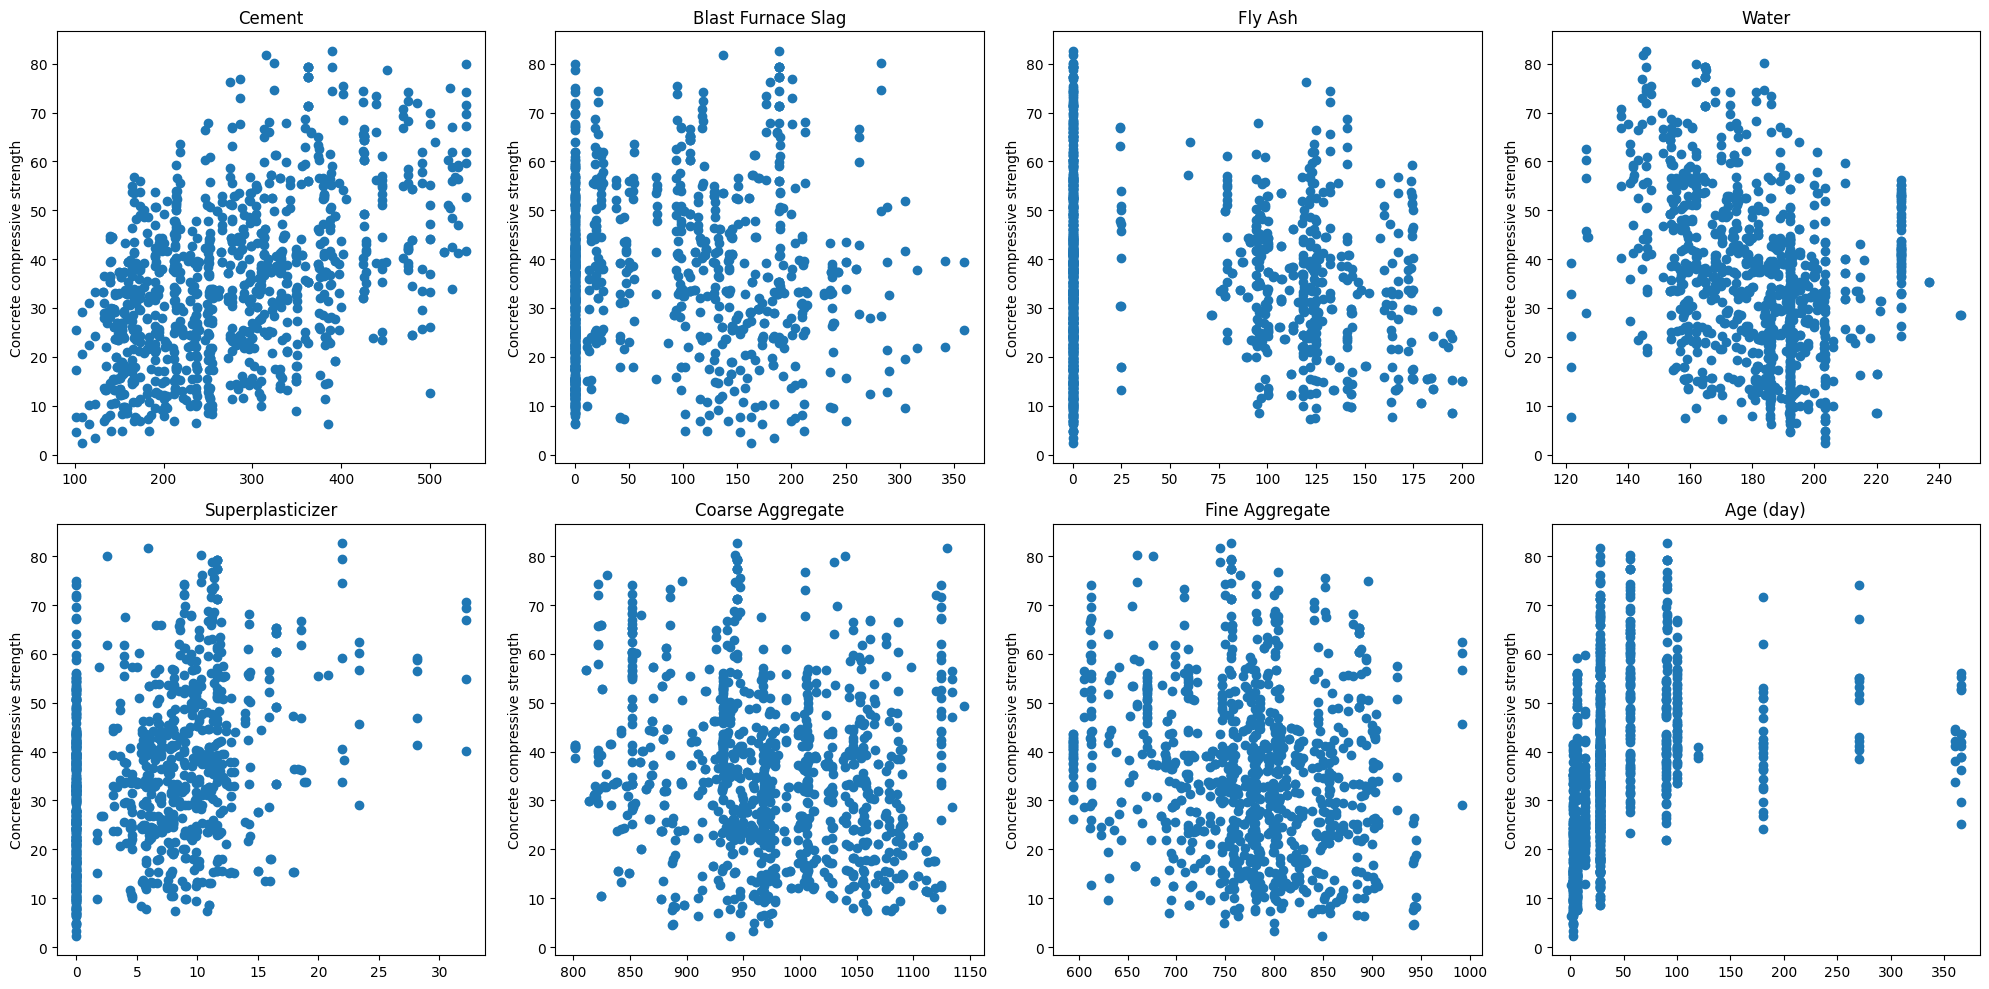

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))

axes[0,0].plot(df['Cement'], df['Concrete compressive strength '], 'o')
axes[0,0].set_ylabel("Concrete compressive strength")
axes[0,0].set_title("Cement")

axes[0,1].plot(df['Blast Furnace Slag'], df['Concrete compressive strength '], 'o')
axes[0,1].set_title("Blast Furnace Slag")
axes[0,1].set_ylabel("Concrete compressive strength")

axes[0,2].plot(df['Fly Ash'], df['Concrete compressive strength '], 'o')
axes[0,2].set_title("Fly Ash")
axes[0,2].set_ylabel("Concrete compressive strength")

axes[0,3].plot(df['Water'], df['Concrete compressive strength '], 'o')
axes[0,3].set_title("Water")
axes[0,3].set_ylabel("Concrete compressive strength")

axes[1,0].plot(df['Superplasticizer'], df['Concrete compressive strength '], 'o')
axes[1,0].set_title("Superplasticizer")
axes[1,0].set_ylabel("Concrete compressive strength")

axes[1,1].plot(df['Coarse Aggregate'], df['Concrete compressive strength '], 'o')
axes[1,1].set_title("Coarse Aggregate")
axes[1,1].set_ylabel("Concrete compressive strength")

axes[1,2].plot(df['Fine Aggregate'], df['Concrete compressive strength '], 'o')
axes[1,2].set_title("Fine Aggregate")
axes[1,2].set_ylabel("Concrete compressive strength")

axes[1,3].plot(df['Age (day)'], df['Concrete compressive strength '], 'o')
axes[1,3].set_title("Age (day)")
axes[1,3].set_ylabel("Concrete compressive strength")

plt.tight_layout()

ОПИСАНИЕ СВЯЗИ С ПРОЧТНОСТЬЮ ЦЕМЕНТА
1. Цемент (Cement) — сильная положительная связь. Чем больше цемента в смеси, тем выше прочность бетона 
2. Доменный шлак (Blast Furnace Slag) — слабая положительная связь. Влияние минимально, возможно, шлак вносит вклад только при длительном твердении, поэтому линейная корреляция невелика. 
3. Зола-унос (Fly Ash) — слабая отрицательная связь. Может указывать на то, что при прочих равных зола немного снижает раннюю прочность. 
4. Вода (Water) — отрицательная связь. избыток воды ухудшает прочность из-за увеличения водоцементного отношения. 
5. Суперпластификатор (Superplasticizer) — положительная связь. Его добавление улучшает прочность, поскольку позволяет снизить расход воды при сохранении удобоукладываемости. 
6. Крупный заполнитель (Coarse Aggregate) — слабая отрицательная связь. 
7. Мелкий заполнитель (Fine Aggregate)  — слабая отрицательная связь. 
8. Возраст образца (Age) — умеренная положительная связь. Чем дольше бетон твердее, тем выше его прочность.


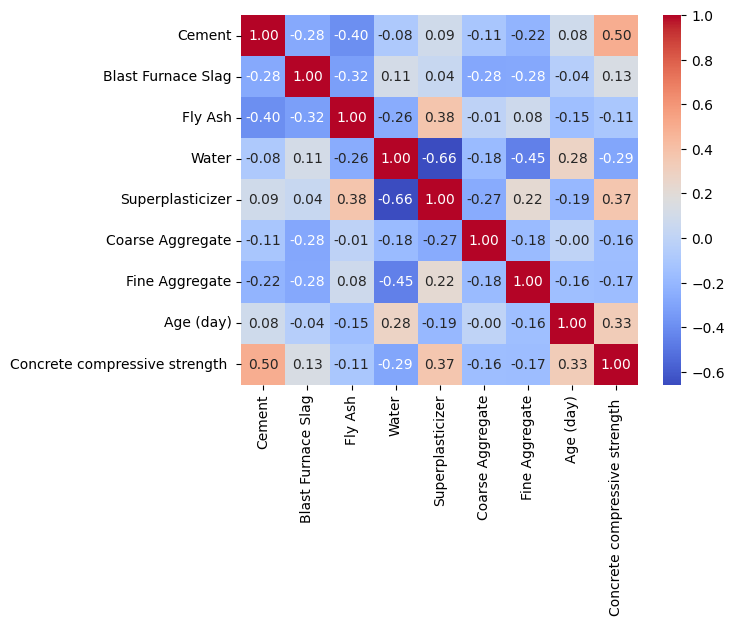

In [15]:
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

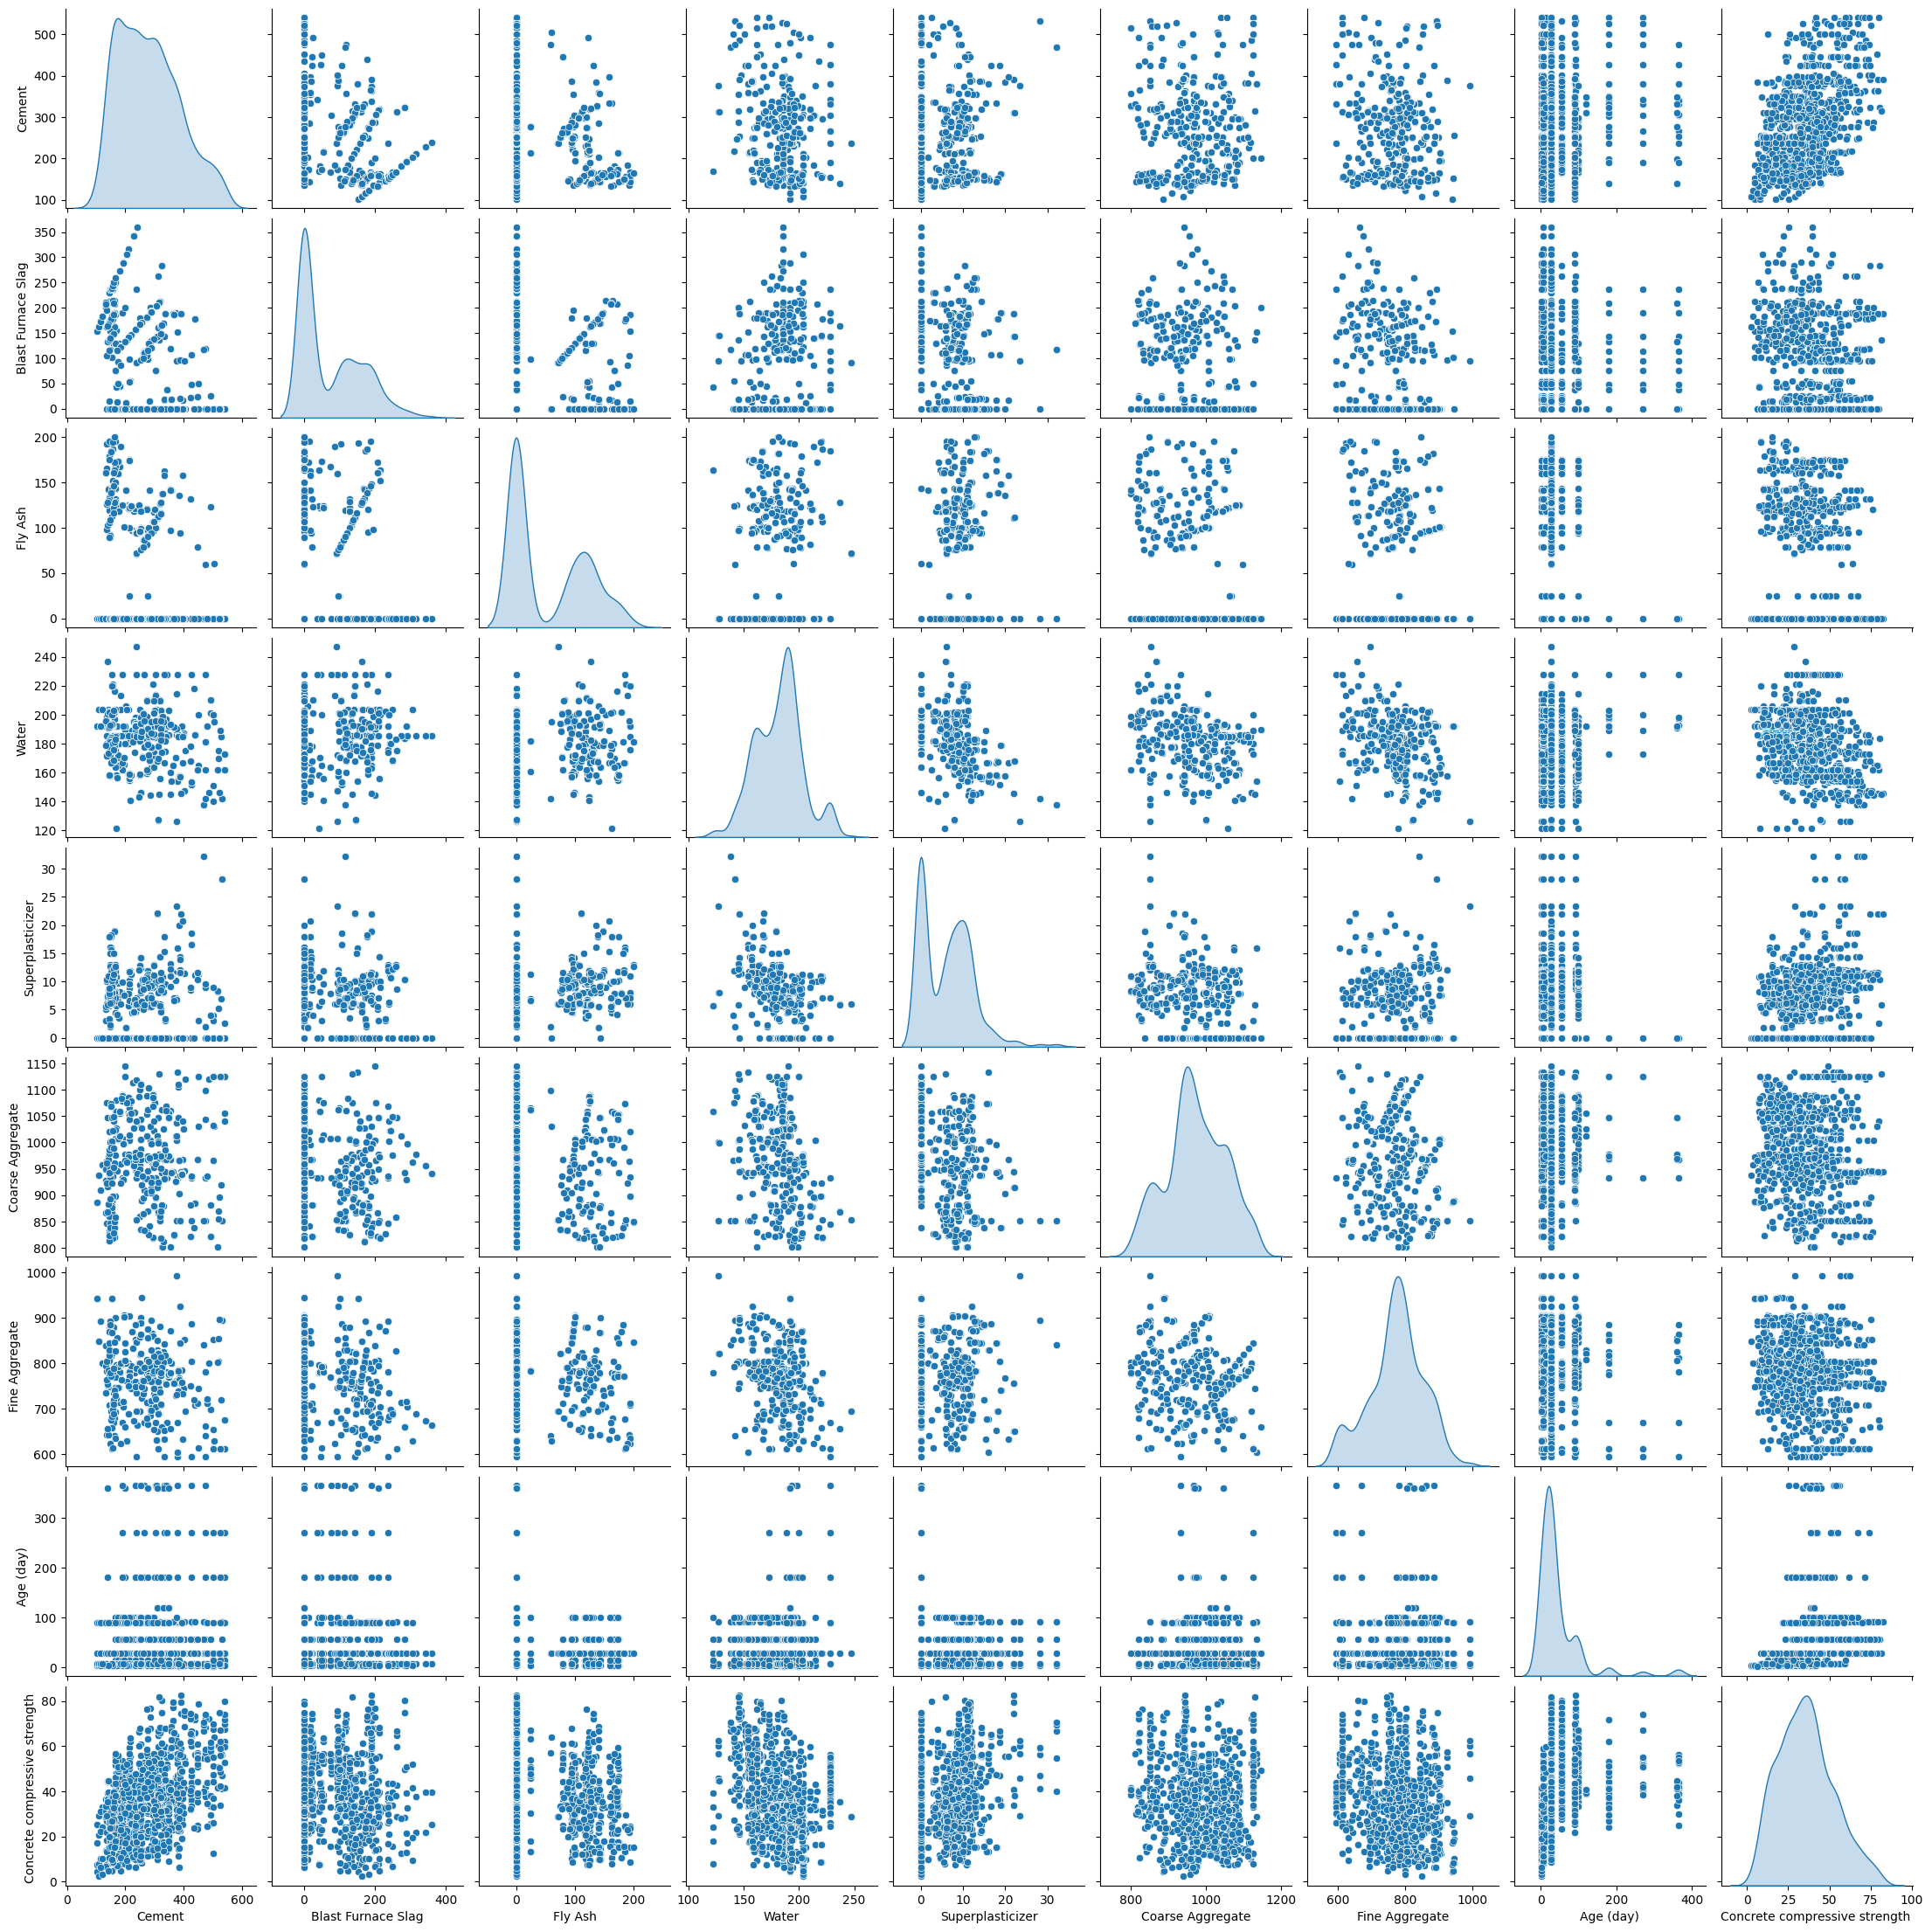

In [16]:
sns.pairplot(df, diag_kind='kde')

На диагонали отображается распределение признака

Вне диагонали отображаются точечные диаграммы между каждой парой признаков

------------
# Задание 2

# Построить и обучить модель простой линейной регрессии

# Модель 1

# SciKit Learn

In [17]:
from sklearn.model_selection import train_test_split

разобьем данные на признаки и целевую переменную

In [18]:
X = df.drop('Concrete compressive strength ', axis=1)
y = df['Concrete compressive strength ']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [20]:
X_train

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age (day)
196,194.68,0.0,100.52,165.62,7.48,1006.4,905.90,28
631,325.00,0.0,0.00,184.00,0.00,1063.0,783.00,7
81,318.80,212.5,0.00,155.70,14.30,852.1,880.40,3
526,359.00,19.0,141.00,154.00,10.91,942.0,801.00,3
830,162.00,190.0,148.00,179.00,19.00,838.0,741.00,28
...,...,...,...,...,...,...,...,...
87,286.30,200.9,0.00,144.70,11.20,1004.6,803.70,3
330,246.83,0.0,125.08,143.30,11.99,1086.8,800.89,14
466,190.34,0.0,125.18,166.61,9.88,1079.0,798.90,100
121,475.00,118.8,0.00,181.10,8.90,852.1,781.50,28


In [21]:
y_train

196    25.724350
631    17.540269
81     25.200348
526    23.639177
830    33.756745
         ...    
87     24.400556
330    42.216615
466    33.563692
121    68.299493
860    38.458971
Name: Concrete compressive strength , Length: 721, dtype: float64

In [22]:
len(X_test)

309

# Масштабирование

In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
scaler = StandardScaler()

In [25]:
scaler.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [26]:
X_train = scaler.transform(X_train)

In [27]:
X_test = scaler.transform(X_test)

# Создаём модель

In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
model = LinearRegression()

In [30]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
model.predict(X_test)

array([58.57504735, 52.45260803, 64.10542477, 51.99681408, 17.52475822,
       39.59501382, 26.65823233, 45.03359831, 30.0486104 , 37.57580535,
       27.89765125, 19.09784563, 68.04009097, 52.75209712, 30.01212472,
       44.32222404, 29.17851117, 26.34893715, 32.15306403, 32.35591276,
       36.66984261, 31.61981735, 38.55399371, 25.05929092, 32.81848049,
       34.56866584, 14.60378741, 40.05211442, 41.86352172, 21.0350626 ,
       35.30346703, 30.51099918, 43.39339578, 45.46205927, 31.11058479,
       29.08237973, 29.49268523, 38.62442885, 20.43472484, 38.7226507 ,
       21.29200171, 16.11500654, 31.16081174, 51.48092385, 20.88482357,
       57.93499638, 51.04728239, 59.76068149, 20.17329791, 19.32472416,
       40.38374696, 35.78563857, 29.86134962, 33.48866724, 46.54284745,
       51.8957266 , 28.45333159, 15.78997941, 30.12624922, 18.20968721,
       38.37882512, 19.58827592, 31.93782676, 56.11230154, 22.88593483,
       21.31701385, 32.44678829, 16.79579322, 26.11432518, 26.07

In [32]:
test_predictions = model.predict(X_test)

In [33]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

среднее арифметическое

In [34]:
df['Concrete compressive strength '].mean()

np.float64(35.817835826122334)

гистограмма распределения прочности бетона

<Axes: xlabel='Concrete compressive strength ', ylabel='Count'>

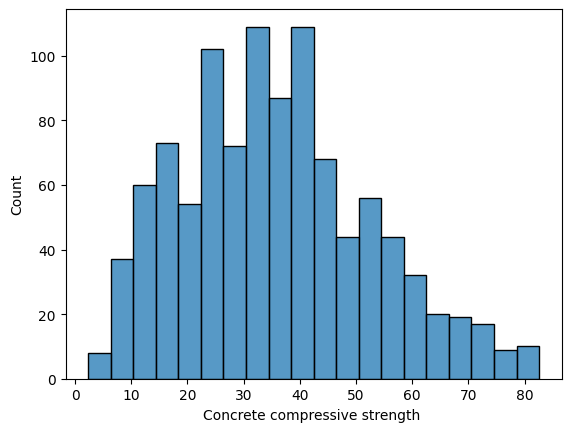

In [35]:
sns.histplot(data=df, x='Concrete compressive strength ', bins=20)

### Метрики

Для регрессионных задач наиболее часто используются следующие три метрики:

**Средняя абсолютная ошибка - Mean Absolute Error** (MAE) - усредняет абсолютные значения ошибок:

$$\frac 1n\sum_{i=1}^n|y_i-\hat{y}_i|$$

**Среднеквадратическая ошибка - Mean Squared Error** (MSE) - усредняет квадраты ошибок:

$$\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2$$

**Среднеквадратическое отклонение - Root Mean Squared Error** (RMSE) - квадратный корень от среднеквадратической ошибки:

$$\sqrt{\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2}$$

Сравнение метрик:

- **MAE** проще всего понять - это просто средняя ошибка.
- **MSE** более популярнее MAE, потому что MSE больше "наказывает" большие ошибки, и обычно это более полезно в прикладных задачах.
- **RMSE** даже ещё более популярна, чем MSE, потому что RMSE измеряется в тех же единицах, что и "y".

Все эти метрики являются **функциями потери (loss functions)**, потому что мы стремимся уменьшить их.

In [37]:
MAE = mean_absolute_error(y_test, test_predictions)
MSE = mean_squared_error(y_test, test_predictions)
RMSE = np.sqrt(MSE)

насколько в среднем модель ошибается при предсказании прочности бетона

In [38]:
MAE

8.298641626746607

In [39]:
MSE

109.7561406377186

In [40]:
RMSE

np.float64(10.476456492427133)

# Остатки

In [41]:
test_predictions = model.predict(X_test)

In [42]:
test_res = y_test - test_predictions
test_res

31     -5.666728
109     3.443211
136    10.392457
88    -16.695643
918    -6.989565
         ...    
250    -0.477342
377     5.867380
615    -4.368398
9       8.971693
357    23.475671
Name: Concrete compressive strength , Length: 309, dtype: float64

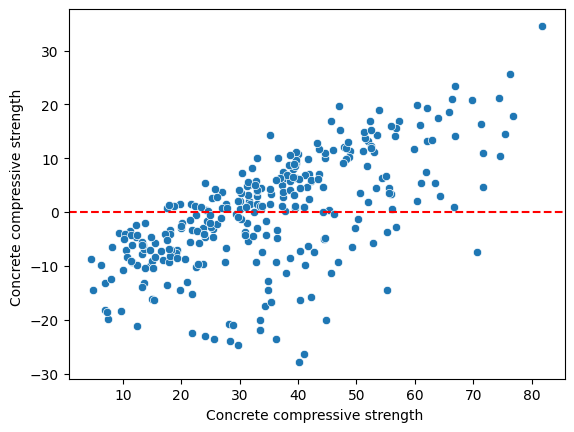

In [43]:
sns.scatterplot(x=y_test, y=test_res)
plt.axhline(y=0, color='r', linestyle='--')

Точки ВЫШЕ красной линии, остаток > 0, y_test > prediction знчаит модель занижает прочность

Точки НИЖЕ красной линии, остаток < 0, y_test < prediction знчаит модель завышает прочность

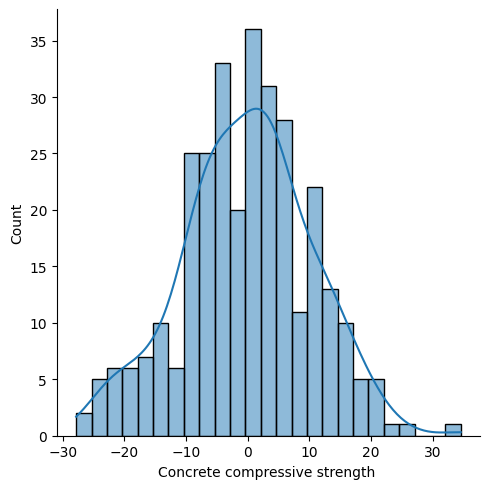

In [44]:
sns.displot(test_res,bins=25,kde=True)

Гистограмма остатков имеет пик около нуля и симметрична это говорит о том, что модель в целом хорошо предсказывает прочность, без особых завышений или занижений

In [ ]:
import scipy as sp

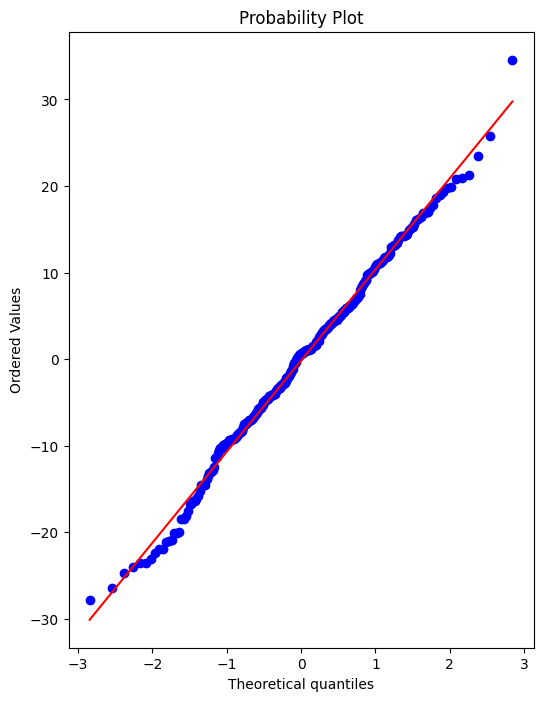

In [46]:
fig, ax = plt.subplots(figsize=(6,8), dpi=100)
_ = sp.stats.probplot(test_res,plot=ax)

график нормальности

Точки близко к линии, значит остатки примерно нормально распределены

# Внедрение модели

In [49]:
final_model = LinearRegression()

In [50]:
final_model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
LinearRegression()

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [52]:
final_model.coef_

array([ 0.11978526,  0.10384725,  0.08794308, -0.1502979 ,  0.29068694,
        0.01803018,  0.02015446,  0.11422562])

In [53]:
y_hat = final_model.predict(X)

In [54]:
y_hat

array([53.4728591 , 53.74331185, 56.81194746, ..., 26.47099254,
       29.11564722, 31.89398622], shape=(1030,))

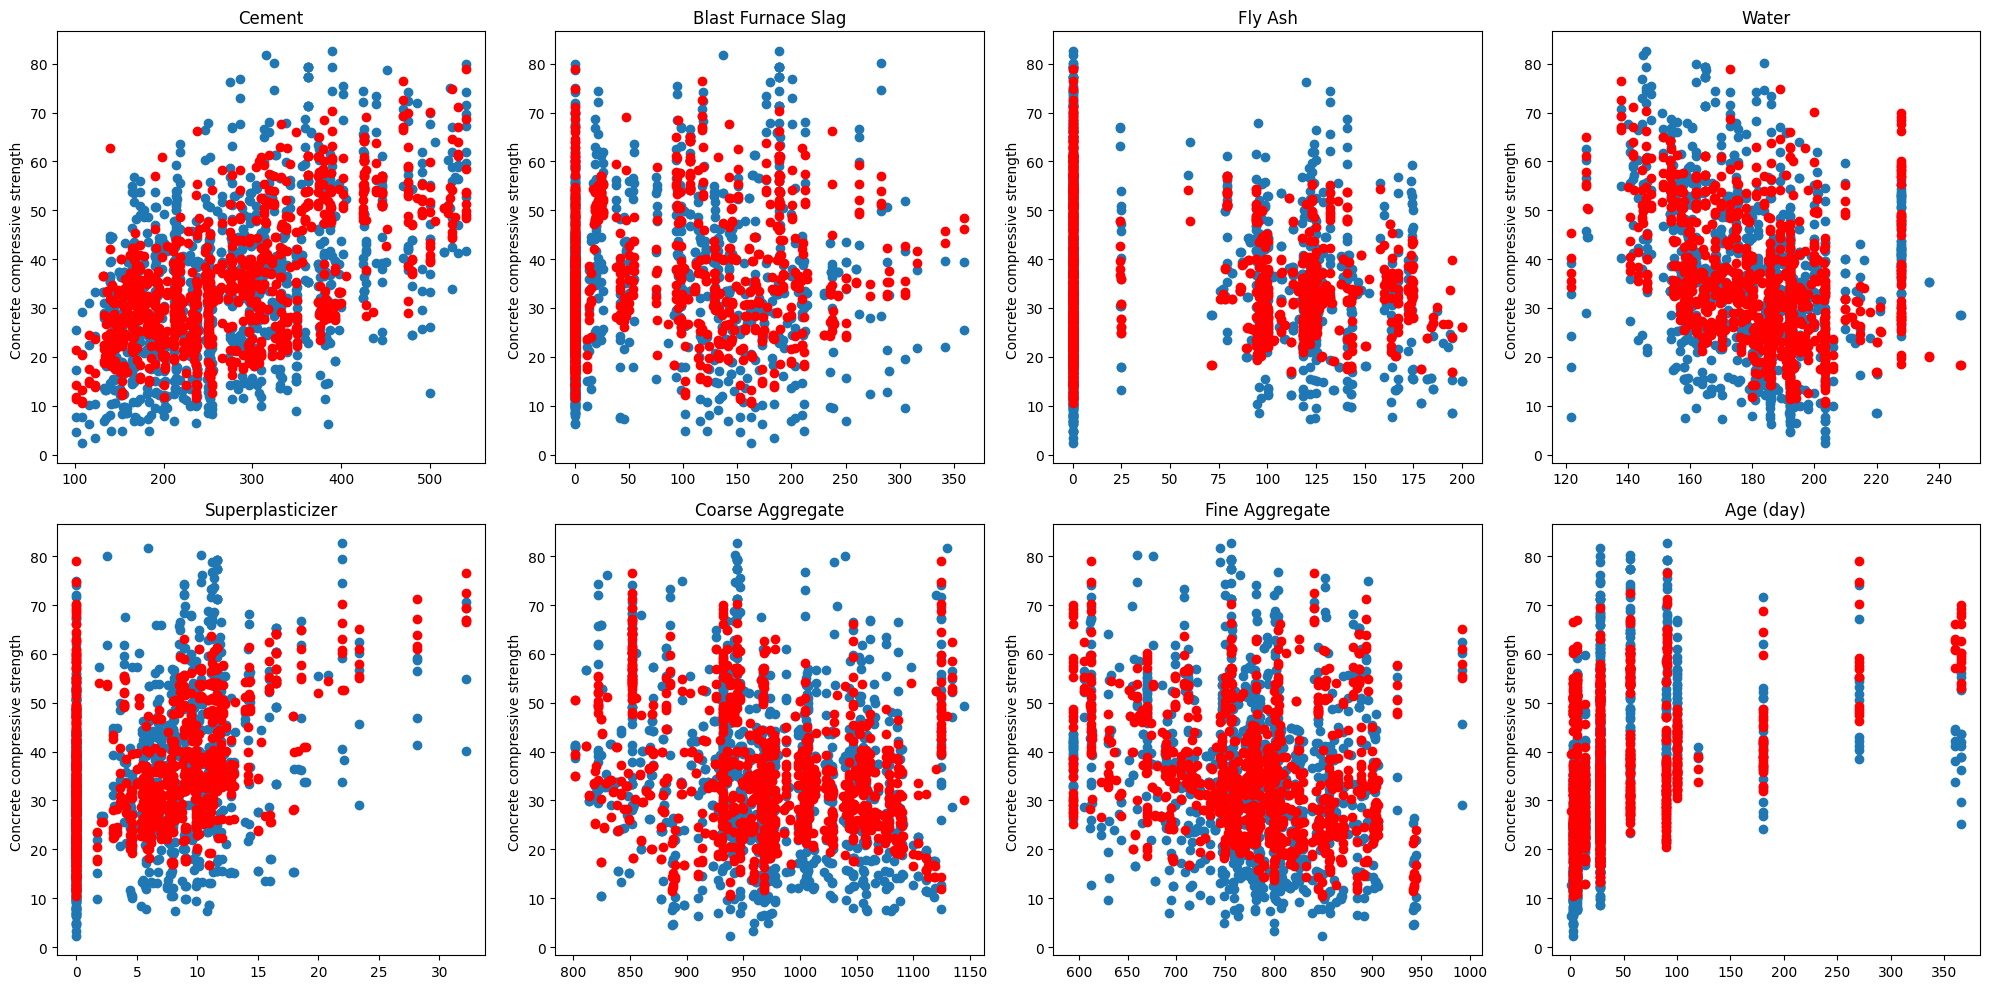

In [55]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes[0,0].plot(df['Cement'], df['Concrete compressive strength '], 'o')
axes[0,0].plot(df['Cement'], y_hat, 'o', color='red')
axes[0,0].set_ylabel("Concrete compressive strength ")
axes[0,0].set_title("Cement")

axes[0,1].plot(df['Blast Furnace Slag'], df['Concrete compressive strength '], 'o')
axes[0,1].plot(df['Blast Furnace Slag'], y_hat, 'o', color='red')
axes[0,1].set_title("Blast Furnace Slag")
axes[0,1].set_ylabel("Concrete compressive strength ")

axes[0,2].plot(df['Fly Ash'], df['Concrete compressive strength '], 'o')
axes[0,2].plot(df['Fly Ash'], y_hat, 'o', color='red')
axes[0,2].set_title("Fly Ash")
axes[0,2].set_ylabel("Concrete compressive strength ")

axes[0,3].plot(df['Water'], df['Concrete compressive strength '], 'o')
axes[0,3].plot(df['Water'], y_hat, 'o', color='red')
axes[0,3].set_title("Water")
axes[0,3].set_ylabel("Concrete compressive strength ")

axes[1,0].plot(df['Superplasticizer'], df['Concrete compressive strength '], 'o')
axes[1,0].plot(df['Superplasticizer'], y_hat, 'o', color='red')
axes[1,0].set_title("Superplasticizer")
axes[1,0].set_ylabel("Concrete compressive strength ")

axes[1,1].plot(df['Coarse Aggregate'], df['Concrete compressive strength '], 'o')
axes[1,1].plot(df['Coarse Aggregate'], y_hat, 'o', color='red')
axes[1,1].set_title("Coarse Aggregate")
axes[1,1].set_ylabel("Concrete compressive strength ")

axes[1,2].plot(df['Fine Aggregate'], df['Concrete compressive strength '], 'o')
axes[1,2].plot(df['Fine Aggregate'], y_hat, 'o', color='red')
axes[1,2].set_title("Fine Aggregate")
axes[1,2].set_ylabel("Concrete compressive strength ")

axes[1,3].plot(df['Age (day)'], df['Concrete compressive strength '], 'o')
axes[1,3].plot(df['Age (day)'], y_hat, 'o', color='red')
axes[1,3].set_title("Age (day)")
axes[1,3].set_ylabel("Concrete compressive strength ")

plt.tight_layout()

Синие точки - реальные значения прочности бетона из датасета

Красные точки — предсказанные моделью значения прочности 

# Сохранение и загрузка модели

In [56]:
from joblib import dump, load

In [57]:
dump(final_model, 'Финальная модель.joblib')

['Финальная модель.joblib']

In [58]:
loaded_model = load('Финальная модель.joblib')

In [59]:
final_model.coef_

array([ 0.11978526,  0.10384725,  0.08794308, -0.1502979 ,  0.29068694,
        0.01803018,  0.02015446,  0.11422562])

прогноз с хорошим составом

In [65]:
new_data = [[540.0, 0.0, 0.0, 162.0, 2.5, 1040.0, 676.0, 28]]

реальные данные из датасета

In [61]:
new_data = [[198.6, 132.4, 0.0, 192.0, 0, 978, 825, 360]]

In [66]:
prediction = loaded_model.predict(new_data)


/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [67]:
prediction[0]

np.float64(53.47285909983055)

53.47 МПа - прогнозируемая прочность бетона для хорошего состава:

Высокое содержание цемента (540 кг/м³)

Оптимальное количество воды (162 кг/м³)

Наличие пластификатора

Возраст 28 дней

Результат: качественный бетон с нормальной прочностью

In [68]:
loaded_model_bad = load('Финальная модель.joblib')

плохой состав

In [116]:
new_data_bad = [[100.0, 0.0, 0.0, 250.0, 0.0, 800.0, 500.0, 1]]

In [70]:
prediction_bad = loaded_model.predict(new_data_bad)

/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [71]:
prediction_bad[0]

np.float64(-24.14410605571407)

-24.14 МПа - прогнозируемая прочность для плохого состава:

Очень мало цемента (100 кг/м³)

Слишком много воды (250 кг/м³)

Нет пластификатора, значит нельзя уменьшить воду, не делая смесь неработоспособной

Всего 1 день возраста

как итог отрицательное значение, модель показывает, что такой бетон не будет держать нагрузку вообще



В целом модель правильно улавливает физические закономерности, хороший состав дает положительную прочность, а плохой состав приводит к разрушению 

# Построить и обучить модель полиномиальной регрессии: модель 2

In [72]:
from sklearn.preprocessing import PolynomialFeatures

In [73]:
polynomial_converter = PolynomialFeatures(degree=2, include_bias=False)

In [74]:
poly_features = polynomial_converter.fit_transform(X)

размерность данных после преобразования transform

In [75]:
poly_features.shape

(1030, 44)

размерность данных до преобразования

In [76]:
X.shape

(1030, 8)

In [77]:
X.iloc[0]

Cement                 540.0
Blast Furnace Slag       0.0
Fly Ash                  0.0
Water                  162.0
Superplasticizer         2.5
Coarse Aggregate      1040.0
Fine Aggregate         676.0
Age (day)               28.0
Name: 0, dtype: float64

In [78]:
poly_features[0]

array([5.40000e+02, 0.00000e+00, 0.00000e+00, 1.62000e+02, 2.50000e+00,
       1.04000e+03, 6.76000e+02, 2.80000e+01, 2.91600e+05, 0.00000e+00,
       0.00000e+00, 8.74800e+04, 1.35000e+03, 5.61600e+05, 3.65040e+05,
       1.51200e+04, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
       0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
       0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 2.62440e+04,
       4.05000e+02, 1.68480e+05, 1.09512e+05, 4.53600e+03, 6.25000e+00,
       2.60000e+03, 1.69000e+03, 7.00000e+01, 1.08160e+06, 7.03040e+05,
       2.91200e+04, 4.56976e+05, 1.89280e+04, 7.84000e+02])

Разобьем все данные на обучающие и тестовые наборы

In [79]:
X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)

Модель для обучения на полиномиальных данных

In [80]:
model = LinearRegression(fit_intercept=True)

In [81]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# Оценка работы модели на тестовых данных

In [92]:
test_predictions = model.predict(X_test)

In [93]:
model.coef_

array([ 6.62840758e-23, -8.08473228e-24,  4.92085870e-24, ...,
       -6.93420528e-19, -1.04683107e-18, -1.31752361e-18], shape=(24309,))

In [94]:
MAE = mean_absolute_error(y_test, test_predictions)
MSE = mean_squared_error(y_test, test_predictions)
RMSE = np.sqrt(MSE)

In [95]:
MAE

2219.3507251210635

In [96]:
MSE

79841526.00370044

In [97]:
RMSE

np.float64(8935.408552702022)

In [98]:
df['Concrete compressive strength '].mean()

np.float64(35.817835826122334)

Сравнение с простой линейной регрессией

Результаты на тестовом наборе данных

Простая линейная регрессия:

- MAE: 8.299

- RMSE: 10.476

Полиномиальная регрессия 2й степени:

- MAE: 6.024

- RMSE: 7.784

подбор оптимальной степени полинома

In [99]:
train_rmse_errors = []
test_rmse_errors = []

for d in range(1,10):

    polynomial_converter = PolynomialFeatures(degree=d, include_bias=False)
    poly_features = polynomial_converter.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)

    model = LinearRegression(fit_intercept=True)
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_RMSE = np.sqrt(mean_squared_error(y_train, train_pred))

    test_RMSE = np.sqrt(mean_squared_error(y_test, test_pred))

    train_rmse_errors.append(train_RMSE)
    test_rmse_errors.append(test_RMSE)

In [100]:
train_rmse_errors

[np.float64(10.185077805753831),
 np.float64(7.1923394065303),
 np.float64(4.3477251750748485),
 np.float64(2.087161616462475),
 np.float64(0.9579878709039505),
 np.float64(0.36874117073924534),
 np.float64(0.20296788502116977),
 np.float64(0.2109988492318044),
 np.float64(0.21143958469360513)]

In [101]:
test_rmse_errors

[np.float64(10.847073987172685),
 np.float64(7.783582466360064),
 np.float64(6.246041229029468),
 np.float64(64.02055943102563),
 np.float64(8269.928232469614),
 np.float64(67975.19411418287),
 np.float64(8513.208515288861),
 np.float64(8216.316554736042),
 np.float64(8935.408552702022)]

При низких степенях (1–3) и обучающая и тестовая уменьшаются, значит модель становится лучше

Начиная с степени 4
- Обучающая ошибка продолжает падать почти до нуля, получается модель запоминает данные
- Тестовая ошибка резко взлетает до 8269 -это сильное переобучение

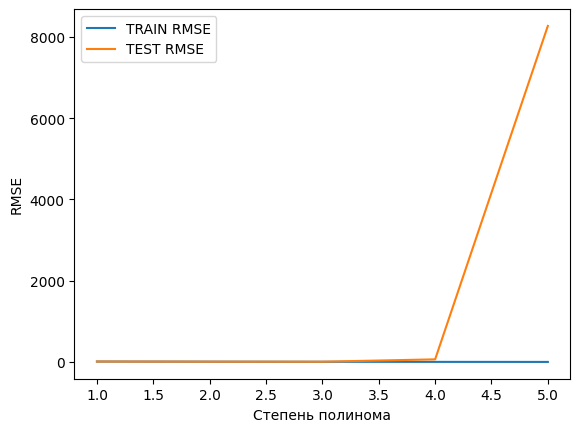

In [103]:
plt.plot(range(1,6),train_rmse_errors[:5],label='TRAIN RMSE')
plt.plot(range(1,6),test_rmse_errors[:5],label='TEST RMSE')
plt.xlabel("Степень полинома")
plt.ylabel("RMSE")
plt.legend()

Синяя линия почти плоская, потом немного падает

Оранжевая линия резко взлетает начиная с 4

То есть на степени 4 модель уже не работает на новых данных

Поэтому оптимальной является степень 3, где тестовая ошибка минимальна и модель ещё обобщает данные

# Финальный выбор модели

In [104]:
final_poly_converter = PolynomialFeatures(degree=3, include_bias=False)

In [105]:
final_model = LinearRegression()

In [106]:
final_model.fit(final_poly_converter.fit_transform(X),y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [107]:
dump(final_model, 'Финальная модель полином.joblib')

['Финальная модель полином.joblib']

In [108]:
dump(final_poly_converter, 'Конвертер.joblib')

['Конвертер.joblib']

In [109]:
loaded_converter = load('Конвертер.joblib')
loaded_model = load('Финальная модель полином.joblib')

прогноз с хорошим составом


In [117]:
new_data = [[540.0, 0.0, 0.0, 162.0, 2.5, 1040.0, 676.0, 28]]

In [118]:
loaded_converter.fit_transform(new_data)

array([[5.40000000e+02, 0.00000000e+00, 0.00000000e+00, 1.62000000e+02,
        2.50000000e+00, 1.04000000e+03, 6.76000000e+02, 2.80000000e+01,
        2.91600000e+05, 0.00000000e+00, 0.00000000e+00, 8.74800000e+04,
        1.35000000e+03, 5.61600000e+05, 3.65040000e+05, 1.51200000e+04,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 2.62440000e+04, 4.05000000e+02, 1.68480000e+05,
        1.09512000e+05, 4.53600000e+03, 6.25000000e+00, 2.60000000e+03,
        1.69000000e+03, 7.00000000e+01, 1.08160000e+06, 7.03040000e+05,
        2.91200000e+04, 4.56976000e+05, 1.89280000e+04, 7.84000000e+02,
        1.57464000e+08, 0.00000000e+00, 0.00000000e+00, 4.72392000e+07,
        7.29000000e+05, 3.03264000e+08, 1.97121600e+08, 8.16480000e+06,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.000000

In [119]:
loaded_converter.fit_transform(new_data).shape

(1, 164)

In [120]:
transformed_data = loaded_converter.fit_transform(new_data)

In [121]:
loaded_model.predict(transformed_data)

array([66.1326417])

Более приближенное к исходным данным значение, в отличие от линейной регрессии

реальные данные из датасета

In [122]:
new_datar = [[198.6, 132.4, 0.0, 192.0, 0, 978, 825, 360]]

плохой состав

In [ ]:

new_data_bad = [[100.0, 0.0, 0.0, 250.0, 0.0, 800.0, 500.0, 1]]

In [123]:
loaded_converter.fit_transform(new_datar)

array([[1.98600000e+02, 1.32400000e+02, 0.00000000e+00, 1.92000000e+02,
        0.00000000e+00, 9.78000000e+02, 8.25000000e+02, 3.60000000e+02,
        3.94419600e+04, 2.62946400e+04, 0.00000000e+00, 3.81312000e+04,
        0.00000000e+00, 1.94230800e+05, 1.63845000e+05, 7.14960000e+04,
        1.75297600e+04, 0.00000000e+00, 2.54208000e+04, 0.00000000e+00,
        1.29487200e+05, 1.09230000e+05, 4.76640000e+04, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 3.68640000e+04, 0.00000000e+00, 1.87776000e+05,
        1.58400000e+05, 6.91200000e+04, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 9.56484000e+05, 8.06850000e+05,
        3.52080000e+05, 6.80625000e+05, 2.97000000e+05, 1.29600000e+05,
        7.83317326e+06, 5.22211550e+06, 0.00000000e+00, 7.57285632e+06,
        0.00000000e+00, 3.85742369e+07, 3.25396170e+07, 1.41991056e+07,
        3.48141034e+06, 0.00000000e+00, 5.04857088e+06, 0.000000

In [124]:
loaded_converter.fit_transform(new_datar).shape

(1, 164)

In [125]:
transformed_data = loaded_converter.fit_transform(new_datar)

In [126]:
loaded_model.predict(transformed_data)

array([41.91228617])

Более приближённое к реальности значение, в отличие от линейной регрессии